# 04 - Sensitivity and Rank Stability

## Objective
Test whether acquisition recommendations remain attractive when economic, demand, competition, network, and weighting assumptions change.

## Data source
Official scoring component scores and PostgreSQL scoring configuration.

## Methodology
Run the documented validation business and weight scenarios through the scoring scenario function, compare Top 10/20 membership and segment counts, and calculate per-lot average/best/worst rank plus Top-10 and Top-20 frequency.

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

cwd = Path.cwd().resolve()
REPO_ROOT = next(path for path in (cwd, *cwd.parents) if (path / 'database').exists() and (path / 'python').exists())
sys.path.insert(0, str(REPO_ROOT))

from python.analysis.data_access import load_analysis_inputs
from python.model_validation.sensitivity import (
    default_weight_map, locality_scenario_summary, rank_stability,
    revenue_sensitivity_grid, run_business_scenarios, scenario_summary,
    segment_thresholds,
)

In [2]:
inputs = load_analysis_inputs(['component_scores', 'acquisition_scores', 'scoring_weights', 'segment_rules'])
weights = default_weight_map(inputs['scoring_weights'])
thresholds = segment_thresholds(inputs['segment_rules'])
scenario_scores = run_business_scenarios(inputs['component_scores'], weights, thresholds)
summary = scenario_summary(scenario_scores)
stability = rank_stability(scenario_scores)
localities = locality_scenario_summary(scenario_scores)
revenue_lot, revenue_portfolio = revenue_sensitivity_grid(inputs['acquisition_scores'])

display(summary)

,scenario_code,scenario_group,description,top_10_overlap_count,top_10_changes,top_20_overlap_count,top_20_changes,average_acquisition_score,mean_abs_rank_change,max_abs_rank_change,acquire_now_count,pursue_count,develop_count,avoid_count,segment_change_count
0,BASE_CASE,Base,Official scoring baseline assumptions and weig...,10,0,20,0,45.174,0.000,0,25,15,21,59,0
1,CONSERVATIVE,Business,"15% lower demand, 10% lower booking share, 20%...",10,0,19,1,40.453,2.117,11,21,12,13,74,19
2,GROWTH,Business,"15% higher demand, 10% higher booking share an...",9,1,20,0,48.430,1.350,7,32,22,22,44,22
3,ACQUISITION_COST_PRESSURE,Business,Onboarding cost increases to 1.5x while all ot...,10,0,20,0,44.866,0.300,2,20,20,19,61,7
4,COMPETITIVE_PRESSURE,Business,Competition opportunity scores deteriorate by ...,10,0,18,2,43.306,1.850,9,24,12,17,67,9
5,NETWORK_EXPANSION,Business,Planned hypothetical sites are treated as part...,10,0,20,0,45.049,0.550,13,25,15,21,59,0
6,DEMAND_HEAVY,Weights,Demand-led allocation: 40/20/15/15/10.,9,1,20,0,43.890,3.733,16,24,14,19,63,7
7,REVENUE_HEAVY,Weights,Revenue-led allocation: 20/40/15/15/10.,9,1,18,2,44.919,3.733,18,29,14,20,57,10
8,FEASIBILITY_HEAVY,Weights,Feasibility-led allocation: 25/20/15/15/25.,9,1,19,1,46.971,3.967,20,26,18,21,55,5
9,STRATEGIC_GROWTH,Weights,Strategic expansion allocation: 25/20/10/30/15.,9,1,18,2,47.348,5.667,22,30,18,18,54,16


In [3]:
display(stability.head(10)[[
    'parking_id', 'parking_name', 'locality_name', 'base_rank', 'average_rank',
    'best_rank', 'worst_rank', 'top_10_frequency_pct', 'top_20_frequency_pct',
    'stability_class',
]])
display(stability.sort_values(['rank_standard_deviation', 'worst_rank'], ascending=[False, False]).head(10)[[
    'parking_id', 'parking_name', 'base_rank', 'best_rank', 'worst_rank',
    'rank_standard_deviation', 'stability_class',
]])
display(localities[localities['scenario_code'].isin(['BASE_CASE', 'CONSERVATIVE', 'STRATEGIC_GROWTH'])].head(30))
display(revenue_portfolio.head(15))

,parking_id,parking_name,locality_name,base_rank,average_rank,best_rank,worst_rank,top_10_frequency_pct,top_20_frequency_pct,stability_class
0,52,MCD Parking,Lajpat Nagar,1,1.27,1,2,100.00,100.0,Very Stable
1,18,OSM Parking node-786590777,Nehru Place,2,2.27,1,4,100.00,100.0,Very Stable
2,1,OSM Parking node-928559154,Connaught Place,3,3.91,3,5,100.00,100.0,Very Stable
3,17,OSM Parking way-1265773838,Nehru Place,6,4.73,2,6,100.00,100.0,Very Stable
4,6,OSM Parking node-928558934,Connaught Place,5,5.09,3,7,100.00,100.0,Very Stable
5,41,OSM Parking way-1386106209,Karol Bagh,7,7.18,6,10,100.00,100.0,Very Stable
6,3,Palika Parking,Connaught Place,8,7.91,7,9,100.00,100.0,Very Stable
7,51,OSM Parking way-1384231629,Lajpat Nagar,4,4.64,1,14,90.91,100.0,Very Stable
8,8,OSM Parking node-5634145022,Connaught Place,9,9.73,7,13,81.82,100.0,Stable
9,13,OSM Parking way-1298783157,Nehru Place,10,10.55,8,15,63.64,100.0,Sensitive


,parking_id,parking_name,base_rank,best_rank,worst_rank,rank_standard_deviation,stability_class
56,48,OSM Parking way-80418116,50,36,83,12.11,Highly Sensitive
91,97,Multi Level Car Parking (MLCP) Noida,91,75,104,7.83,Highly Sensitive
74,82,OSM Parking way-1443588429,78,64,90,7.67,Highly Sensitive
47,53,OSM Parking way-202800243,52,36,60,7.57,Highly Sensitive
76,54,OSM Parking way-1297324904,79,57,85,7.23,Highly Sensitive
73,59,OSM Parking node-449455817,74,63,92,6.99,Highly Sensitive
79,87,OSM Parking way-152002367,77,70,95,6.93,Highly Sensitive
38,49,OSM Parking way-463710736,35,32,53,6.51,Highly Sensitive
78,65,OSM Parking way-692610360,76,72,92,6.47,Highly Sensitive
89,110,OSM Parking way-554394266,90,80,103,6.29,Highly Sensitive


,scenario_code,scenario_group,locality_id,locality_name,parking_count,average_acquisition_score,high_priority_count,expected_monthly_platform_revenue_inr,scenario_locality_rank,base_locality_rank,base_average_acquisition_score,locality_rank_change_vs_base,locality_score_change_vs_base
18,BASE_CASE,Base,2,Nehru Place,11,66.118060,9,1.828740e+06,1,1,66.118060,0,0.000000
17,BASE_CASE,Base,1,Connaught Place,11,63.888567,8,1.385431e+06,2,2,63.888567,0,0.000000
23,BASE_CASE,Base,7,Lajpat Nagar,6,57.633924,2,3.158964e+05,3,3,57.633924,0,0.000000
22,BASE_CASE,Base,6,Karol Bagh,10,56.724031,4,7.439179e+05,4,4,56.724031,0,0.000000
27,BASE_CASE,Base,11,Golf Course Road,5,49.893972,2,2.033449e+05,5,5,49.893972,0,0.000000
21,BASE_CASE,Base,5,Rajouri Garden,5,43.298265,0,1.032765e+05,6,6,43.298265,0,0.000000
20,BASE_CASE,Base,4,Dwarka Sector 21,3,43.077648,0,5.052940e+04,7,7,43.077648,0,0.000000
30,BASE_CASE,Base,14,Noida Sector 62,4,42.727293,0,1.262386e+05,8,8,42.727293,0,0.000000
33,BASE_CASE,Base,19,Faridabad Sector 15,5,41.247066,0,1.334619e+05,9,9,41.247066,0,0.000000
19,BASE_CASE,Base,3,Saket,10,40.093466,0,2.746580e+05,10,10,40.093466,0,0.000000


,occupancy_rate,price_multiplier,commission_scenario,total_expected_monthly_platform_revenue_inr,median_lot_expected_monthly_revenue_inr,mean_lot_expected_monthly_revenue_inr
0,0.4,0.85,DOCUMENTED_PER_LOT,4.888925e+06,23468.497643,40741.037771
1,0.4,0.85,GLOBAL_10_PCT,2.926912e+06,15383.162457,24390.929464
2,0.4,0.85,GLOBAL_15_PCT,4.390367e+06,23074.743685,36586.394196
3,0.4,0.85,GLOBAL_20_PCT,5.853823e+06,30766.324913,48781.858927
4,0.4,0.85,GLOBAL_25_PCT,7.317279e+06,38457.906142,60977.323659
5,0.4,1.00,DOCUMENTED_PER_LOT,5.751676e+06,27609.997227,47930.632671
6,0.4,1.00,GLOBAL_10_PCT,3.443425e+06,18097.838184,28695.211134
7,0.4,1.00,GLOBAL_15_PCT,5.165138e+06,27146.757276,43042.816701
8,0.4,1.00,GLOBAL_20_PCT,6.886851e+06,36195.676369,57390.422268
9,0.4,1.00,GLOBAL_25_PCT,8.608563e+06,45244.595461,71738.027834


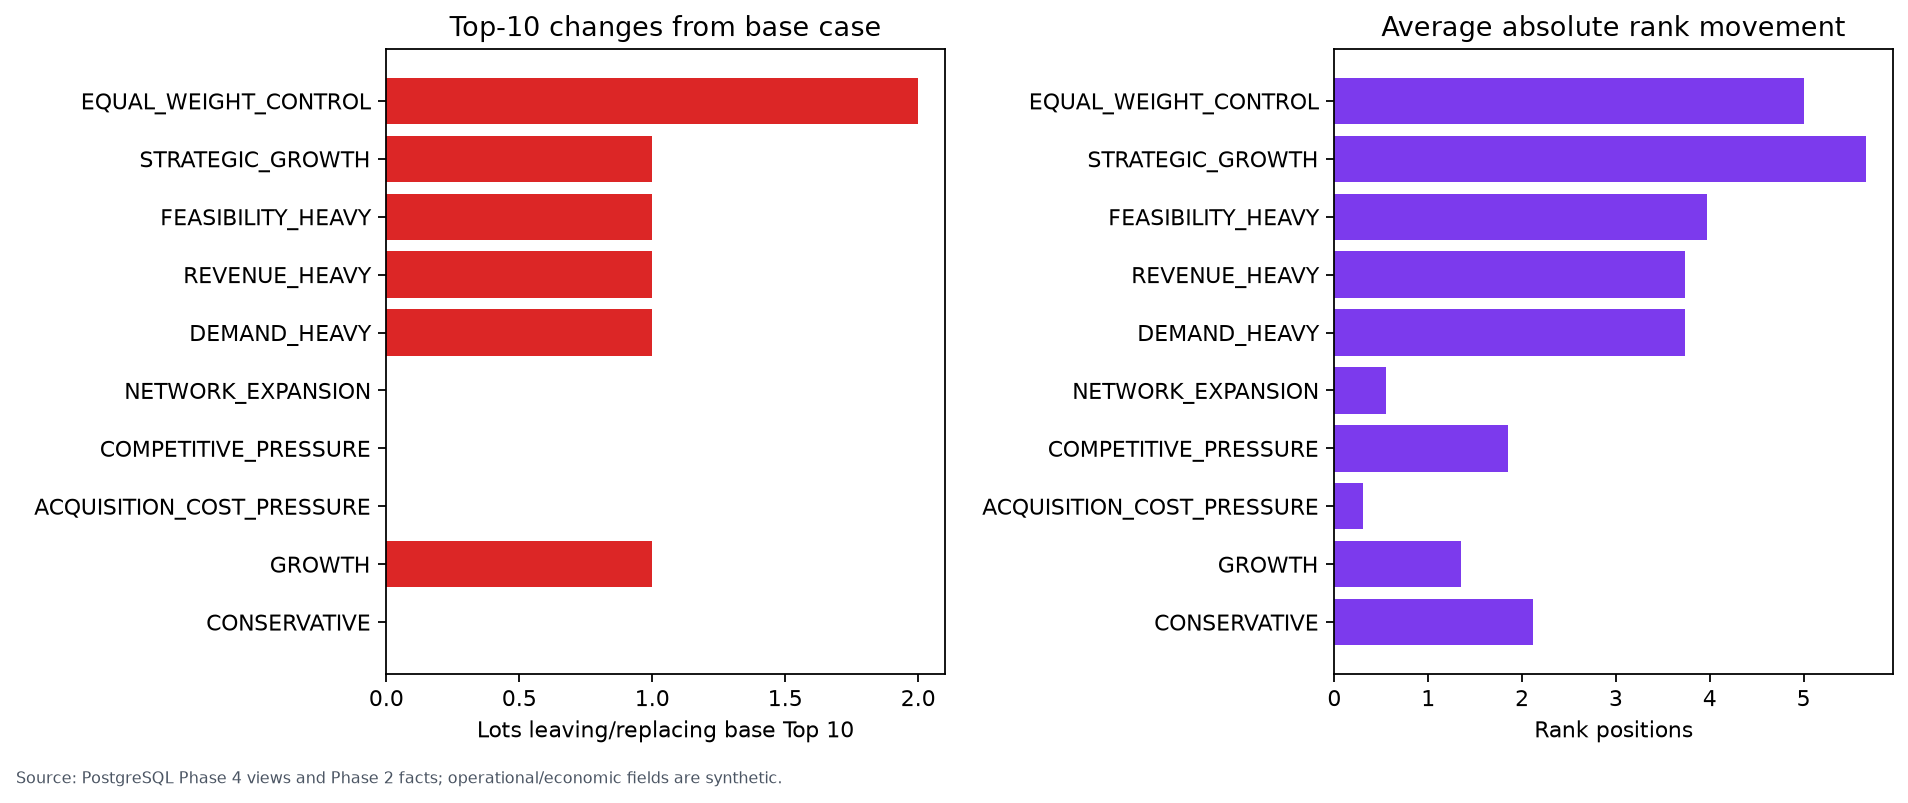

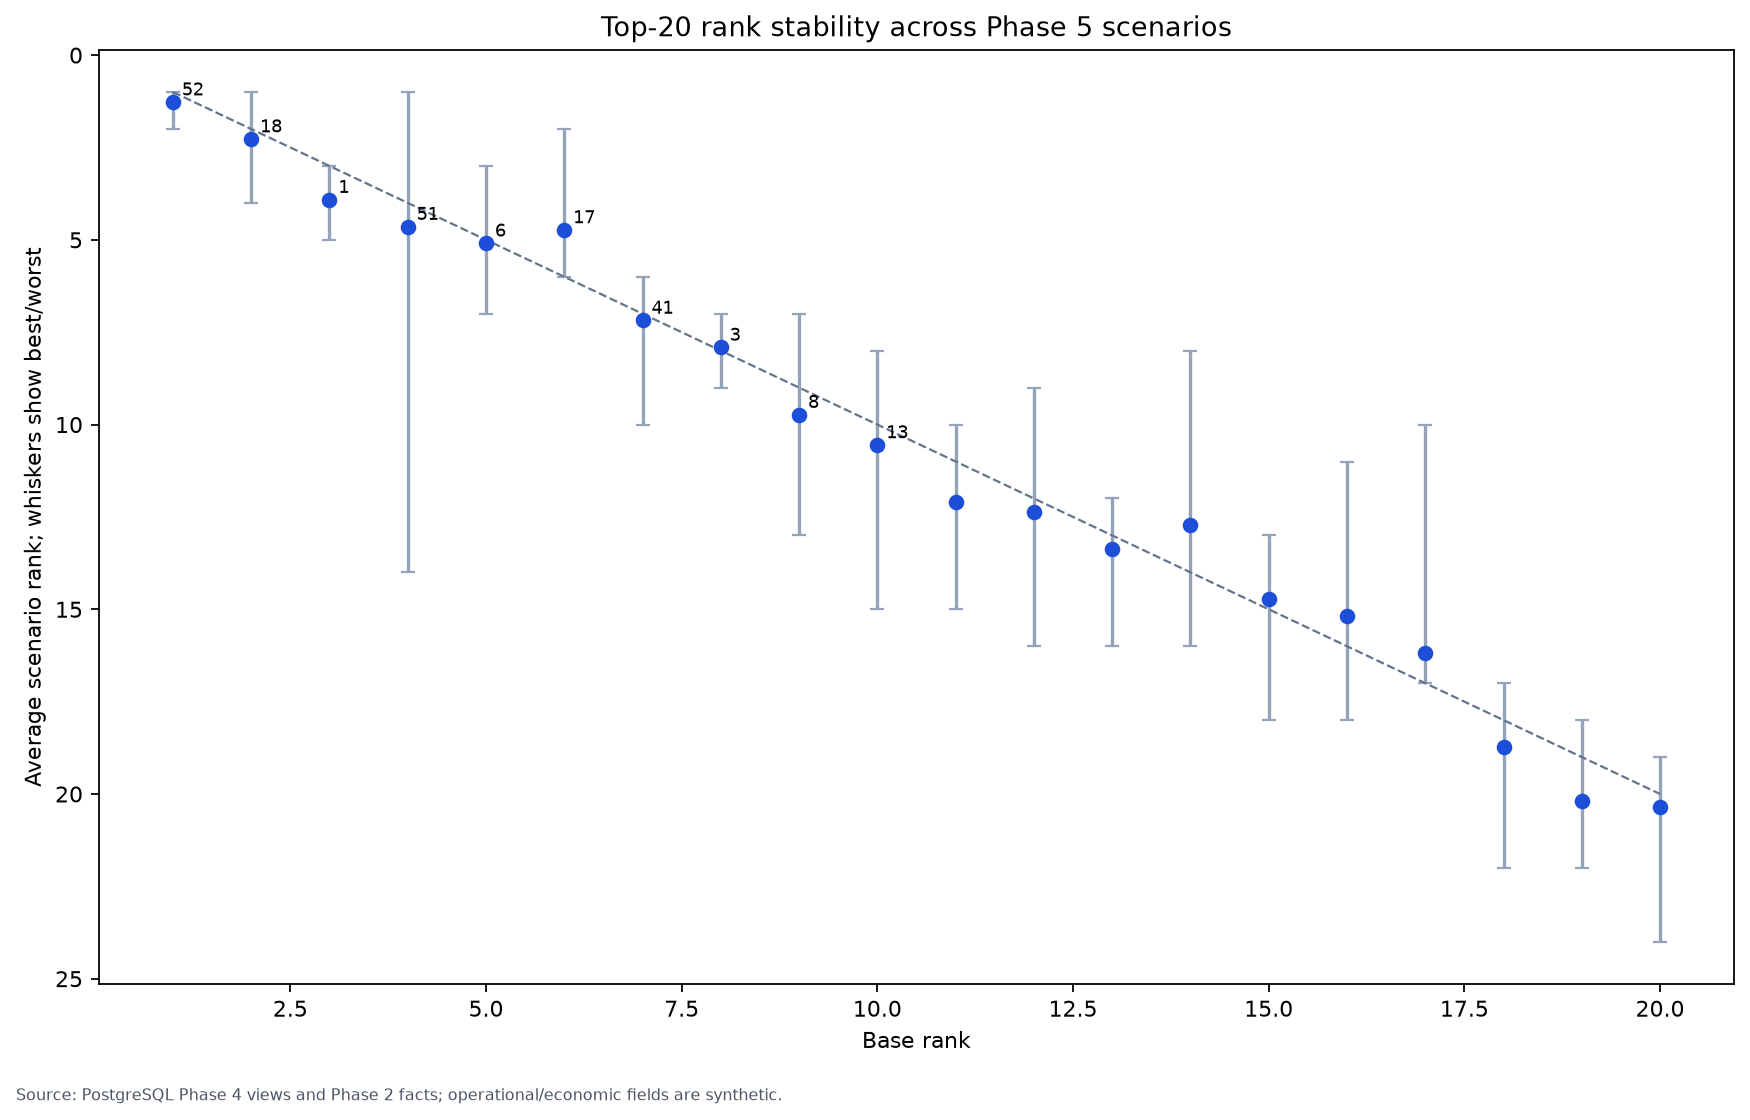

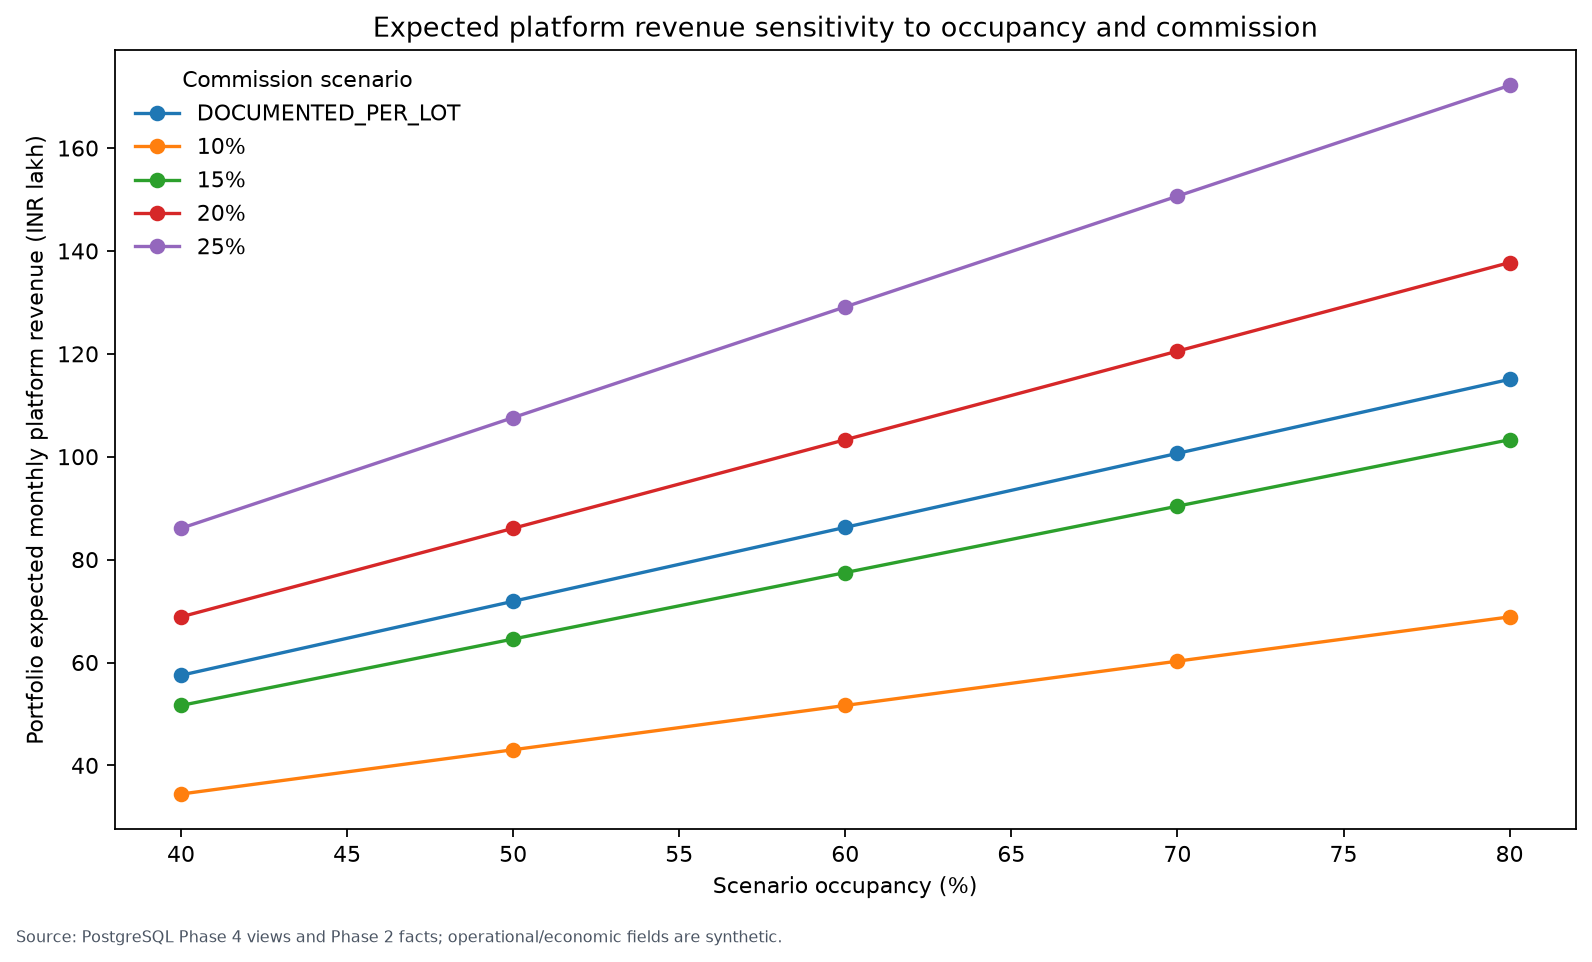

In [4]:
for filename in ['10_scenario_summary.png', '11_rank_stability.png', '12_revenue_sensitivity.png']:
    display(Image(filename=REPO_ROOT / 'validation' / 'figures' / filename, width=900))

## Key findings

- Seven lots remain in the Top 10 in all 11 scenarios: parking IDs 52, 18, 1, 17, 6, 41, and 3.
- MCD Parking (ID 52) is the most robust target: base rank 1, average rank 1.27, and worst rank 2.
- The conservative scenario preserves the entire base Top 10 but lowers the mean score from 45.17 to 40.45, reduces Acquire Now targets from 25 to 21, and moves 19 lots to a different segment.
- Strategic-growth weighting produces the most average rank movement (5.67 places); the equal-weight control changes two Top-10 members and moves one lot by as many as 33 positions.
- Base Top-10 concentration remains led by Connaught Place, Nehru Place, and Lajpat Nagar, but locality ranks and segment counts change under strategic and economic stresses.
- Expected platform revenue increases linearly with the explicit occupancy, price, and commission assumptions used in the transparent sensitivity grid.

## Limitations

Rank stability is conditional on the 11 documented scenarios and their bounds. It does not cover every possible business environment. Revenue sensitivity is gross platform revenue, not profit, because the dataset does not model all operating costs.